<a href="https://colab.research.google.com/github/waleedbar/BitcoinForesight./blob/main/NASA_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install catboost

          ULTRA HIGH ACCURACY EXOPLANET CLASSIFICATION SYSTEM (+90%)
 Data loaded successfully

🔄 Standardizing and merging datasets...
✅ Data unified. Total rows: 25786

Class distribution:
label
2    10973
1     8637
0     6176
Name: count, dtype: int64

 Performing advanced feature engineering...
Retained 18 features after engineering

 Building base models...

Building stacking ensemble...

 Training and Evaluation with Stratified K-Fold Cross-Validation

 Fold 1/5
✅ Fold 1 - Accuracy: 0.8945 | F1-Score: 0.8956

 Fold 2/5
✅ Fold 2 - Accuracy: 0.8868 | F1-Score: 0.8879

 Fold 3/5
✅ Fold 3 - Accuracy: 0.8957 | F1-Score: 0.8968

 Fold 4/5
✅ Fold 4 - Accuracy: 0.8893 | F1-Score: 0.8904

 Fold 5/5
✅ Fold 5 - Accuracy: 0.8918 | F1-Score: 0.8928

📈 Final Results - Cross-Validation

 Mean Accuracy across folds: 0.8916 (±0.0033)
 Overall Accuracy: 0.8916
 Overall F1-Score: 0.8927

Detailed Classification Report:
                precision    recall  f1-score   support

     CONFIRMED       0

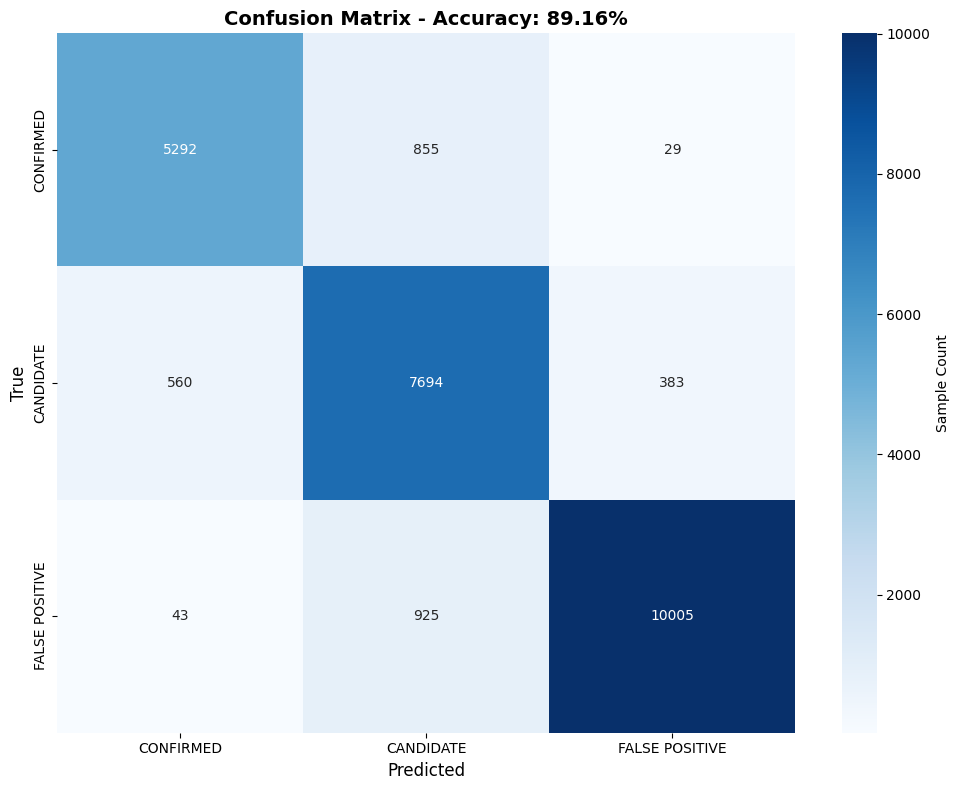


 Training final model and saving...
 Model saved as: 'exoplanet_stacking_model_90plus.pkl'

 Training completed successfully!


In [5]:

import pandas as pd
import numpy as np
import joblib
import warnings
from collections import Counter

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("="*80)
print("          ULTRA HIGH ACCURACY EXOPLANET CLASSIFICATION SYSTEM (+90%)")
print("="*80)

# ====== 1) Load Data ======
def find_data_start_row(filepath):
    try:
        with open(filepath, 'r') as f:
            for i, line in enumerate(f):
                if not line.strip().startswith('#'):
                    return i
    except FileNotFoundError:
        return 0
    return 0

try:
    df_koi = pd.read_csv("cumulative_2025.10.02_12.23.38.csv",
                         skiprows=find_data_start_row("cumulative_2025.10.02_12.23.38.csv"))
    df_toi = pd.read_csv("TOI_2025.10.02_12.24.51.csv",
                         skiprows=find_data_start_row("TOI_2025.10.02_12.24.51.csv"))
    df_k2 = pd.read_csv("cumulative_2025.10.02_12.25.41.csv",
                        skiprows=find_data_start_row("cumulative_2025.10.02_12.25.41.csv"))
    print(" Data loaded successfully")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    exit()

# ====== 2) Standardize and Merge Data ======
print("\n🔄 Standardizing and merging datasets...")

koi_mapping = {
    'orbital_period': 'koi_period',
    'transit_duration': 'koi_duration',
    'transit_depth': 'koi_depth',
    'planet_radius': 'koi_prad',
    'stellar_radius': 'koi_srad',
    'stellar_temp': 'koi_steff',
    'stellar_gravity': 'koi_slogg',
    'snr': 'koi_snr',
    'fp_flag_ss': 'koi_fpflag_ss',
    'fp_flag_co': 'koi_fpflag_co',
    'fp_flag_nt': 'koi_fpflag_nt',
    'fp_flag_ec': 'koi_fpflag_ec',
    'koi_score': 'koi_score',
    'label': 'label',
    'source': 'source'
}

toi_mapping = {
    'orbital_period': 'pl_orbper',
    'transit_duration': 'pl_trandur',
    'transit_depth': 'pl_trandep',
    'planet_radius': 'pl_radj',
    'stellar_radius': 'st_rad',
    'stellar_temp': 'st_teff',
    'stellar_gravity': 'st_logg',
    'label': 'label',
    'source': 'source'
}

k2_mapping = koi_mapping.copy()

def standardize_dataframe(df, mapping, source_name):
    df_copy = df.copy()

    if source_name == 'koi':
        if 'koi_disposition' in df_copy.columns:
            df_copy.rename(columns={'koi_disposition': 'label'}, inplace=True)
    elif source_name == 'toi':
        for col in ['toi_disposition', 'tfopwg_disp', 'Disposition']:
            if col in df_copy.columns:
                df_copy.rename(columns={col: 'label'}, inplace=True)
                break
    elif source_name == 'k2':
        for col in ['pl_disposition', 'disposition', 'k2_disposition', 'koi_disposition']:
            if col in df_copy.columns:
                df_copy.rename(columns={col: 'label'}, inplace=True)
                break

    df_copy['source'] = source_name
    rename_dict = {v: k for k, v in mapping.items() if v in df_copy.columns}
    if not rename_dict:
        return pd.DataFrame()

    return df_copy[list(rename_dict.keys())].rename(columns=rename_dict)

all_dfs = [
    standardize_dataframe(df_koi, koi_mapping, 'koi'),
    standardize_dataframe(df_toi, toi_mapping, 'toi'),
    standardize_dataframe(df_k2, k2_mapping, 'k2')
]

df_all = pd.concat(all_dfs, ignore_index=True, sort=False)

JUPITER_TO_EARTH_RADIUS = 11.209
is_jupiter_radius = df_all['source'].isin(['toi', 'k2'])
df_all.loc[is_jupiter_radius, 'planet_radius'] *= JUPITER_TO_EARTH_RADIUS

df_all['label'] = df_all['label'].replace({
    'CP': 'CONFIRMED',
    'PC': 'CANDIDATE',
    'FP': 'FALSE POSITIVE',
    'FA': 'FALSE POSITIVE'
})

valid_labels = ['CONFIRMED', 'CANDIDATE', 'FALSE POSITIVE']
df_all = df_all[df_all['label'].isin(valid_labels)].copy()
df_all.dropna(subset=['label'], inplace=True)

label_map = {'CONFIRMED': 0, 'CANDIDATE': 1, 'FALSE POSITIVE': 2}
class_names = list(label_map.keys())
df_all['label'] = df_all['label'].map(label_map).astype(int)

print(f"✅ Data unified. Total rows: {len(df_all)}")
print("\nClass distribution:")
print(df_all['label'].value_counts())

# ====== 3) Feature Engineering ======
print("\n Performing advanced feature engineering...")

y = df_all['label'].values
X = df_all.drop(columns=['label', 'source'])

with np.errstate(divide='ignore', invalid='ignore'):
    X['radius_ratio'] = X['planet_radius'] / X['stellar_radius']
    X['density_proxy'] = X['planet_radius'] / (X['orbital_period'] ** (2/3))
    X['insolation_flux'] = (X['stellar_temp'] / 5778) ** 4 * (X['stellar_radius'] ** 2) / (X['orbital_period'] ** (2/3))
    X['temp_gravity_interaction'] = X['stellar_temp'] * X['stellar_gravity']
    X['period_depth_ratio'] = X['orbital_period'] / (X['transit_depth'] + 1e-10)
    X['duration_period_ratio'] = X['transit_duration'] / X['orbital_period']

X.replace([np.inf, -np.inf], np.nan, inplace=True)
missing_pct = X.isnull().mean()
keep_cols = missing_pct[missing_pct < 0.65].index.tolist()
X = X[keep_cols]

print(f"Retained {len(keep_cols)} features after engineering")

# ====== 4) Preprocessing Pipeline ======
num_cols = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", KNNImputer(n_neighbors=7)),
        ("power", PowerTransformer(method='yeo-johnson')),
        ("scaler", RobustScaler())
    ]), num_cols)
], remainder='drop')

# ====== 5) Base Models ======
print("\n Building base models...")

base_estimators = [
    ('xgb', xgb.XGBClassifier(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=9,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )),

    ('lgb', LGBMClassifier(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=80,
        max_depth=10,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )),

    ('cat', CatBoostClassifier(
        iterations=600,
        learning_rate=0.03,
        depth=9,
        l2_leaf_reg=3,
        border_count=128,
        auto_class_weights='Balanced',
        verbose=0,
        random_state=42,
        thread_count=-1
    )),

    ('rf', RandomForestClassifier(
        n_estimators=400,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )),

    ('et', ExtraTreesClassifier(
        n_estimators=400,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
]

meta_learner = LogisticRegression(
    C=0.5,
    max_iter=2000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# ====== 6) Stacking Classifier ======
print("\nBuilding stacking ensemble...")

smote = SMOTE(random_state=42, k_neighbors=5)

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    verbose=1
)

full_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('sampler', smote),
    ('stacking', stacking_clf)
])

# ====== 7) Training and Cross-Validation ======
print("\n" + "="*80)
print(" Training and Evaluation with Stratified K-Fold Cross-Validation")
print("="*80)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
all_y_true = []
all_y_pred = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n{'='*80}")
    print(f" Fold {fold}/5")
    print(f"{'='*80}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    full_pipeline.fit(X_train, y_train)
    y_pred = full_pipeline.predict(X_val)

    fold_accuracy = accuracy_score(y_val, y_pred)
    fold_f1 = f1_score(y_val, y_pred, average='weighted')

    cv_scores.append(fold_accuracy)
    all_y_true.extend(y_val)
    all_y_pred.extend(y_pred)

    print(f"✅ Fold {fold} - Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")

# ====== 8) Final Results ======
print("\n" + "="*80)
print("📈 Final Results - Cross-Validation")
print("="*80)

final_accuracy = accuracy_score(all_y_true, all_y_pred)
final_f1 = f1_score(all_y_true, all_y_pred, average='weighted')

print(f"\n Mean Accuracy across folds: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f" Overall Accuracy: {final_accuracy:.4f}")
print(f" Overall F1-Score: {final_f1:.4f}")

print("\n" + "="*80)
print("Detailed Classification Report:")
print("="*80)
print(classification_report(all_y_true, all_y_pred, target_names=class_names))

# ====== 9) Confusion Matrix ======
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Sample Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title(f'Confusion Matrix - Accuracy: {final_accuracy:.2%}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ====== 10) Save Final Model ======
print("\n Training final model and saving...")

full_pipeline.fit(X, y)

model_package = {
    'model': full_pipeline,
    'feature_names': X.columns.tolist(),
    'class_names': class_names,
    'cv_accuracy': final_accuracy,
    'cv_f1_score': final_f1
}

joblib.dump(model_package, 'exoplanet_stacking_model_90plus.pkl', compress=3)
print(" Model saved as: 'exoplanet_stacking_model_90plus.pkl'")

print("\n" + "="*80)
print(" Training completed successfully!")
print("="*80)


In [6]:
!ls -lh


total 95M
drwxr-xr-x 4 root root 4.0K Oct  5 09:10 catboost_info
-rw-r--r-- 1 root root 3.5M Oct  5 09:06 cumulative_2025.10.02_12.23.38.csv
-rw-r--r-- 1 root root 3.5M Oct  5 09:06 cumulative_2025.10.02_12.25.41.csv
-rw-r--r-- 1 root root  85M Oct  5 11:58 exoplanet_stacking_model_90plus.pkl
drwxr-xr-x 1 root root 4.0K Oct  2 13:36 sample_data
-rw-r--r-- 1 root root 3.8M Oct  5 09:06 TOI_2025.10.02_12.24.51.csv


In [7]:
joblib.dump(model_package, '/content/exoplanet_stacking_model_90plus.pkl', compress=3)


['/content/exoplanet_stacking_model_90plus.pkl']

In [8]:
from google.colab import files
files.download('/content/exoplanet_stacking_model_90plus.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>